In [196]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from factor_analyzer import Rotator
import hdbscan
from itertools import product
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')

In [197]:
df = pd.read_excel("Kompilasi Data 1.xlsx")

In [198]:
df.shape

(38, 12)

In [199]:
df.head()

,Provinsi,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,jumlah_UMKM_Nonpertanian,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
0,Aceh,74.03,99.416552,40.01,37.65,108507,624542,5086801,75.99,5.12,198.69,0.99
1,Sumatera Utara,74.02,96.515622,36.27,35.38,123911,1485080,7957689,73.15,2.72,172.37,4.06
2,Sumatera Barat,74.49,98.445998,42.26,28.75,88053,740347,4567033,75.14,5.56,194.63,3.08
3,Riau,74.79,98.556150,36.58,36.93,54425,580624,3494581,82.49,2.57,156.56,5.66
4,Jambi,73.43,98.802018,33.54,33.90,31268,344836,2065021,85.91,3.65,150.80,4.12


In [200]:
df.tail()

,Provinsi,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,jumlah_UMKM_Nonpertanian,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
33,Papua Barat Daya,68.63,91.950758,NaN,24.68,2861,51425,272521,74.43,5.26,156.89,2.57
34,Papua,73.00,83.764940,33.69,23.29,7499,44768,398165,74.11,7.02,172.14,11.27
35,Papua Selatan,67.90,88.840580,NaN,28.98,4931,17734,363652,73.21,2.91,236.01,1.29
36,Papua Tengah,59.75,44.700855,NaN,28.78,3828,30938,290986,73.28,0.56,156.26,1.75
37,Papua Pegunungan,53.42,43.850688,NaN,2.70,587,1859,51030,57.30,2.89,151.42,0.00


In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Provinsi                  38 non-null     object 
 1   IPM                       38 non-null     float64
 2   Infrastruktur_Desa        38 non-null     float64
 3   IMDI                      34 non-null     float64
 4   Persen_Ecommerce          38 non-null     float64
 5   Jumlah_UMKM               38 non-null     int64  
 6   jumlah_UMKM_Nonpertanian  38 non-null     int64  
 7   nilai_tambah              38 non-null     int64  
 8   Penetrasi_Internet        38 non-null     float64
 9   Pelatihan_TIK             38 non-null     float64
 10  Level_TIK                 38 non-null     float64
 11  Pembayaran_Digital        38 non-null     float64
dtypes: float64(8), int64(3), object(1)
memory usage: 3.7+ KB


In [202]:
#finding missing value
df.isnull().sum()

Provinsi                    0
IPM                         0
Infrastruktur_Desa          0
IMDI                        4
Persen_Ecommerce            0
Jumlah_UMKM                 0
jumlah_UMKM_Nonpertanian    0
nilai_tambah                0
Penetrasi_Internet          0
Pelatihan_TIK               0
Level_TIK                   0
Pembayaran_Digital          0
dtype: int64

In [203]:
df.isnull().sum()/df.shape[0]*100

Provinsi                     0.000000
IPM                          0.000000
Infrastruktur_Desa           0.000000
IMDI                        10.526316
Persen_Ecommerce             0.000000
Jumlah_UMKM                  0.000000
jumlah_UMKM_Nonpertanian     0.000000
nilai_tambah                 0.000000
Penetrasi_Internet           0.000000
Pelatihan_TIK                0.000000
Level_TIK                    0.000000
Pembayaran_Digital           0.000000
dtype: float64

In [204]:
df.duplicated().sum()

np.int64(0)

In [205]:
#identify garbage value (ngecek kemungkinan adanya typo atau rare nilai yg tidak sesuai dgn konsep data)
for col in df.select_dtypes(include="object").columns:
    print(f"\nColumn: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print("Top values:")
    print(df[col].value_counts().head(10))
    print("Rare values:")
    print(df[col].value_counts()[df[col].value_counts() <= 2].head(20))
    print("-" * 50)


Column: Provinsi
Unique values: 38
Top values:
Provinsi
Aceh                    1
Sumatera Utara          1
Sumatera Barat          1
Riau                    1
Jambi                   1
Sumatera Selatan        1
Bengkulu                1
Lampung                 1
Kep. Bangka Belitung    1
Kepulauan Riau          1
Name: count, dtype: int64
Rare values:
Provinsi
Aceh                    1
Sumatera Utara          1
Sumatera Barat          1
Riau                    1
Jambi                   1
Sumatera Selatan        1
Bengkulu                1
Lampung                 1
Kep. Bangka Belitung    1
Kepulauan Riau          1
DKI Jakarta             1
Jawa Barat              1
Jawa Tengah             1
D.I. Yogyakarta         1
Jawa Timur              1
Banten                  1
Bali                    1
Nusa Tenggara Barat     1
Nusa Tenggara Timur     1
Kalimantan Barat        1
Name: count, dtype: int64
--------------------------------------------------


In [206]:
df.describe()

,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,jumlah_UMKM_Nonpertanian,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
count,38.000000,38.000000,34.000000,38.000000,38.000000,3.800000e+01,3.800000e+01,38.000000,38.000000,38.000000,38.000000
mean,72.388421,94.329776,37.999706,35.194474,116143.289474,7.949755e+05,7.301559e+06,75.233158,3.950789,178.023158,4.795526
std,5.150227,12.594180,5.751563,11.993417,215817.567688,1.258747e+06,1.336654e+07,8.370254,1.470327,33.729680,5.114648
min,53.420000,43.850688,20.900000,2.700000,587.000000,1.859000e+03,5.103000e+04,57.300000,0.560000,122.320000,0.000000
25%,71.080000,94.998290,33.865000,28.757500,20746.750000,1.922848e+05,1.024709e+06,69.277500,2.790000,154.947500,2.470000
50%,73.180000,98.708625,37.605000,36.155000,49199.000000,3.415470e+05,3.203949e+06,74.880000,3.855000,170.945000,3.320000
75%,74.345000,99.770628,43.025000,42.222500,106311.750000,7.176338e+05,6.088314e+06,82.247500,5.027500,197.730000,4.800000
max,83.080000,100.000000,47.980000,63.540000,925985.000000,5.429638e+06,5.769454e+07,88.730000,7.460000,257.820000,28.610000


In [207]:
df.describe(include="object")

,Provinsi
count,38
unique,38
top,Aceh
freq,1


Handling Missing Value pake KNN


In [208]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print('Provinsi dengan missing value: ')
print(df[df.isnull().any(axis=1)]['Provinsi'].tolist())

provinsi = df['Provinsi'].copy()
df_num = df.drop(columns=['Provinsi'])

# mencari k dari range 2 - 10
hasil = []
for k in range(2, 11):
    imputer = KNNImputer(n_neighbors=k)
    X_imputed = imputer.fit_transform(df_num)
    X_imputed = pd.DataFrame(X_imputed, columns=df_num.columns)

    # skala
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    # cluster
    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    #eval
    score = silhouette_score(X_scaled, labels)
    hasil.append([k, score])
    print(f'k = {k}, silhoutte score = {score:.4f}')

hasil_df = pd.DataFrame(hasil, columns=['k_imputer', 'silhouette_score'])
print(f'\nHasil evaluasi: ')
print(hasil_df)

# cari best k
best_k = hasil_df.loc[hasil_df['silhouette_score'].idxmax(), 'k_imputer']
print(f'\nK terbaik: {best_k}')

Provinsi dengan missing value: 
['Papua Barat Daya', 'Papua Selatan', 'Papua Tengah', 'Papua Pegunungan']
k = 2, silhoutte score = 0.4695
k = 3, silhoutte score = 0.4697
k = 4, silhoutte score = 0.4700
k = 5, silhoutte score = 0.4700
k = 6, silhoutte score = 0.4700
k = 7, silhoutte score = 0.4700
k = 8, silhoutte score = 0.4698
k = 9, silhoutte score = 0.4698
k = 10, silhoutte score = 0.4697

Hasil evaluasi: 
   k_imputer  silhouette_score
0          2          0.469526
1          3          0.469682
2          4          0.470019
3          5          0.470007
4          6          0.470021
5          7          0.469979
6          8          0.469818
7          9          0.469803
8         10          0.469713

K terbaik: 6


In [209]:
print("Provinsi dengan missing value:")
print(df[df.isnull().any(axis=1)]['Provinsi'].tolist())
imputer = KNNImputer(n_neighbors=6)
df_imputed = pd.DataFrame(imputer.fit_transform(df_num), columns=df_num.columns)
df_imputed.insert(0, 'Provinsi', provinsi.values)
print(f"\nMissing value setelah imputasi: {df_imputed.isnull().sum().sum()}")
print('\nNilai IMDI hasil imputasi: ')
df_imputed[df_imputed['Provinsi'].isin([
    'Papua Barat Daya','Papua Selatan','Papua Tengah','Papua Pegunungan'
])][['Provinsi','IMDI']]

Provinsi dengan missing value:
['Papua Barat Daya', 'Papua Selatan', 'Papua Tengah', 'Papua Pegunungan']

Missing value setelah imputasi: 0

Nilai IMDI hasil imputasi: 


,Provinsi,IMDI
33,Papua Barat Daya,32.19
35,Papua Selatan,32.19
36,Papua Tengah,32.19
37,Papua Pegunungan,32.19


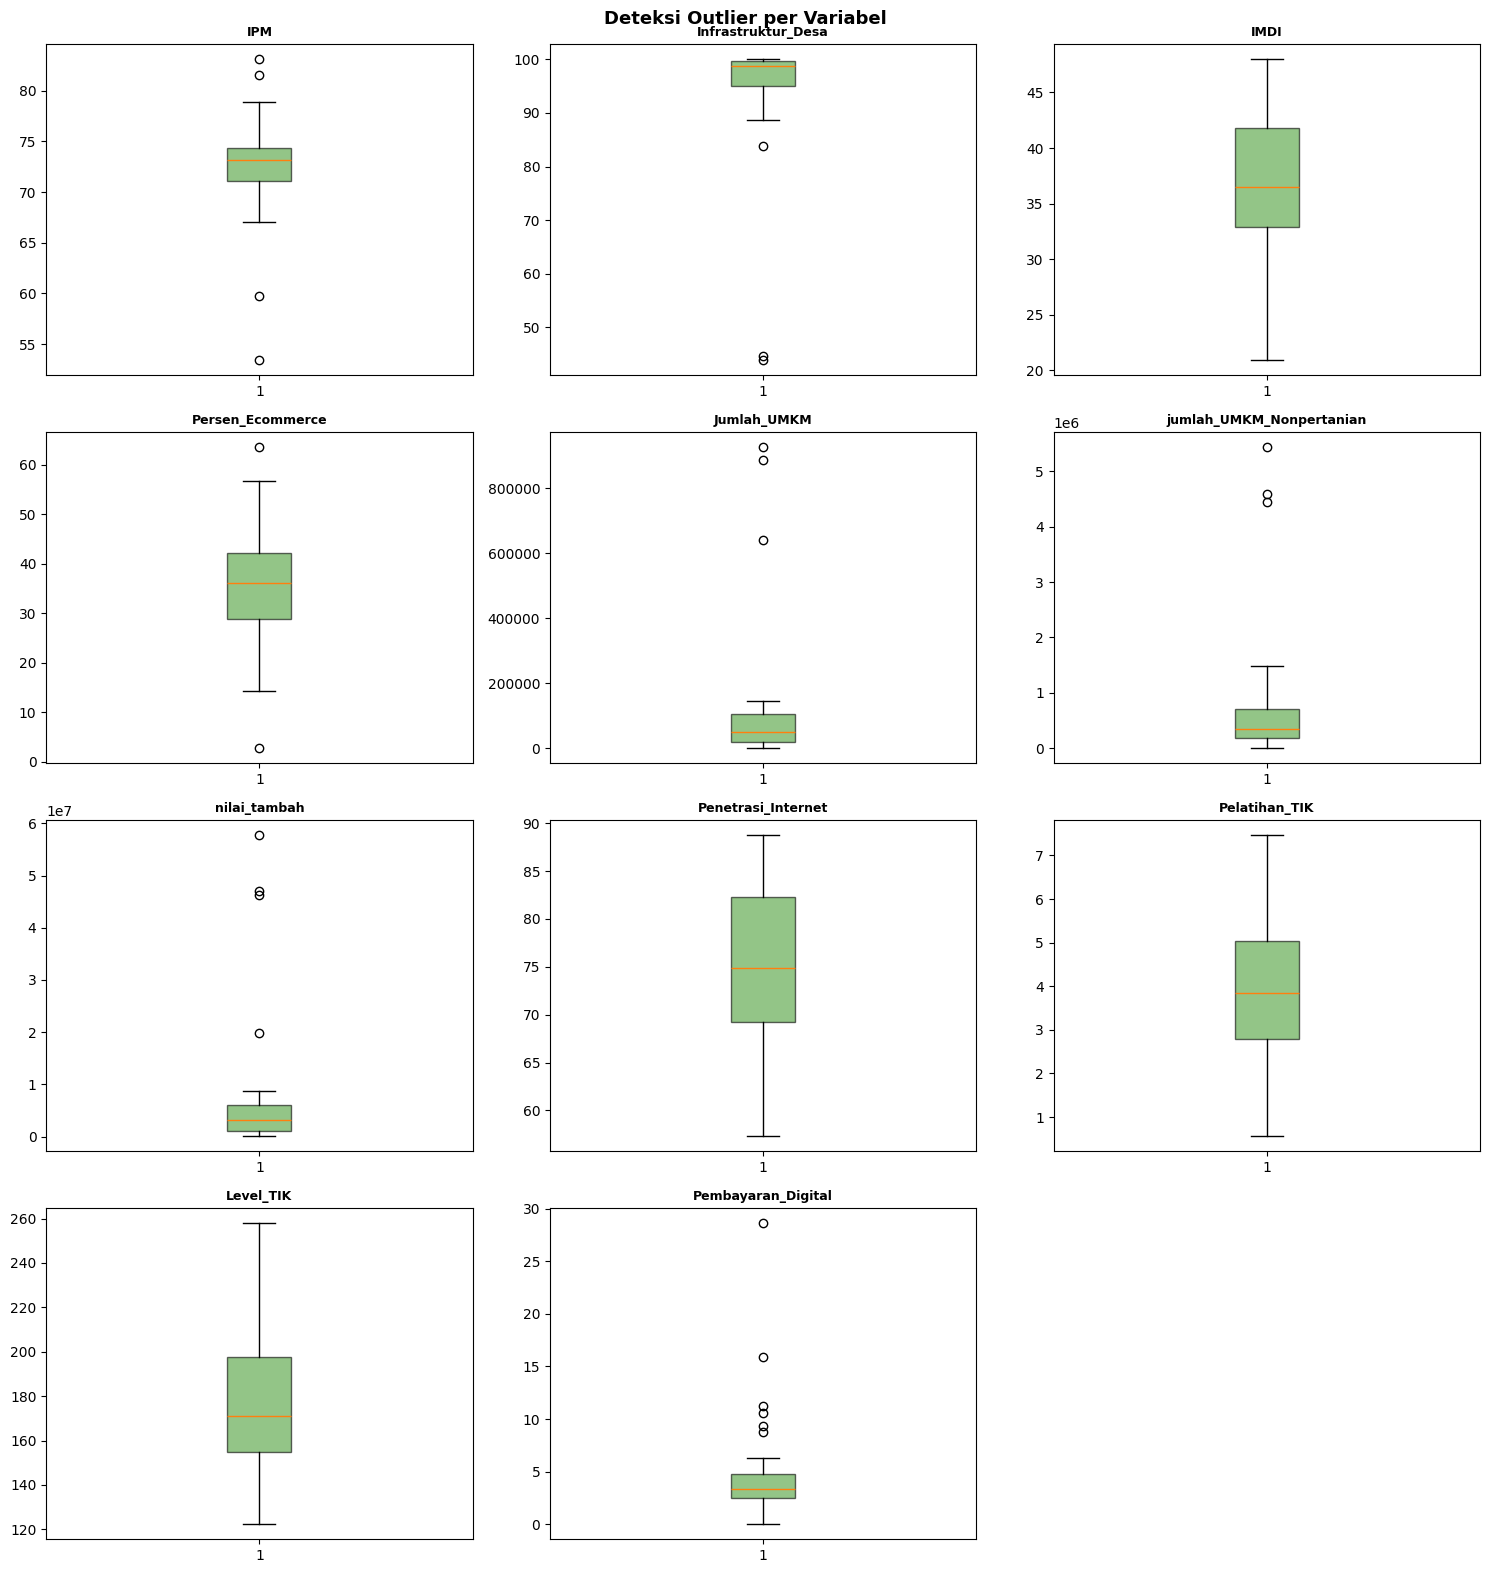

In [210]:
df_num_imp = df_imputed.drop(columns=['Provinsi'])

cols = df_num_imp.columns
n_cols = 3
n_rows = -(-len(cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df_num_imp[col], patch_artist=True,
                    boxprops=dict(facecolor='#4C9F38', alpha=0.6))
    axes[i].set_title(col, fontsize=9, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier per Variabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

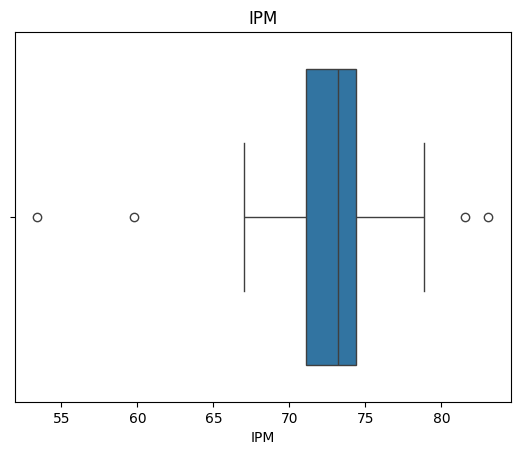

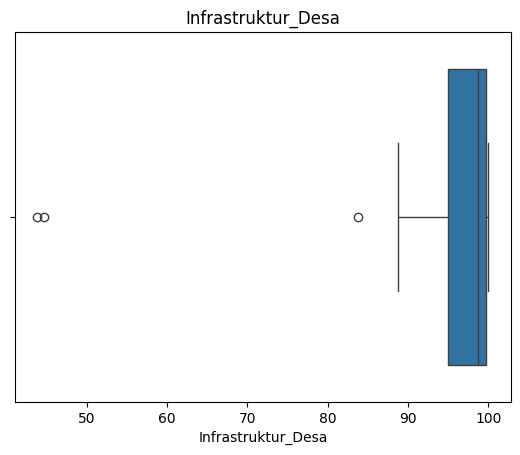

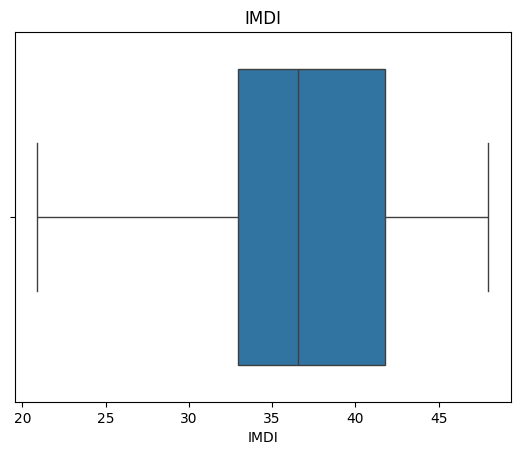

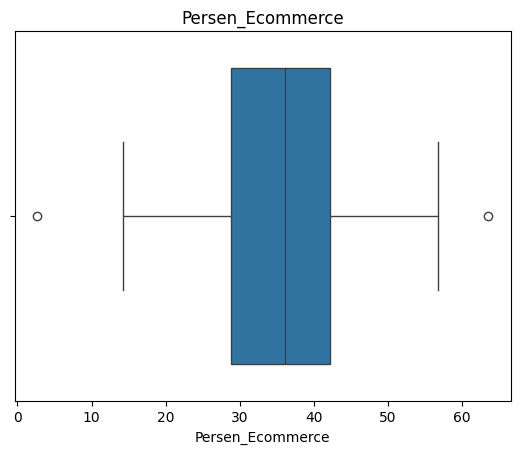

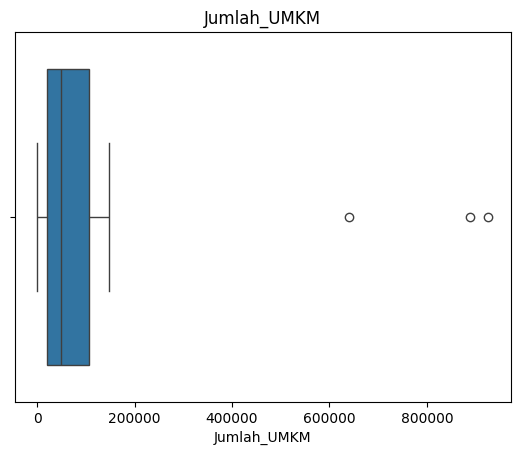

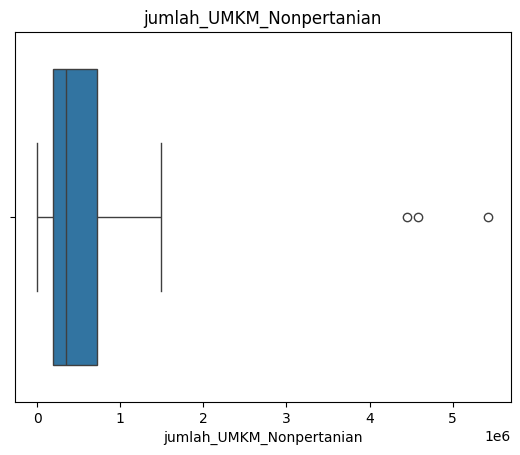

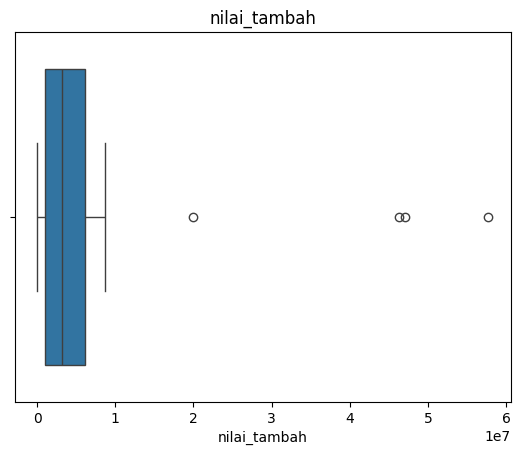

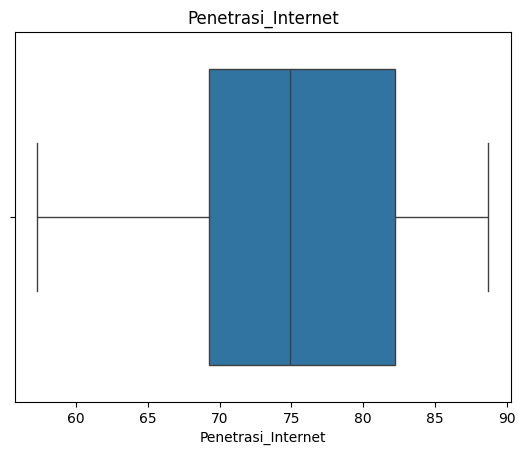

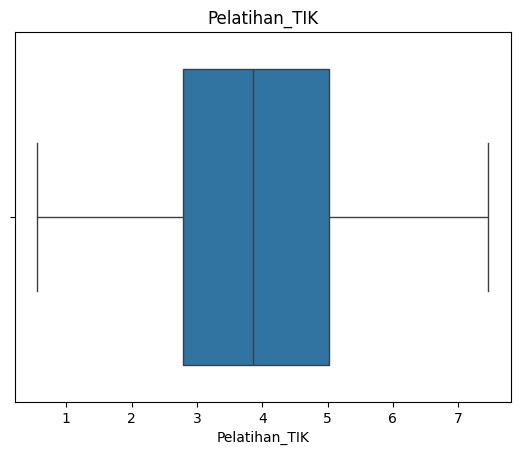

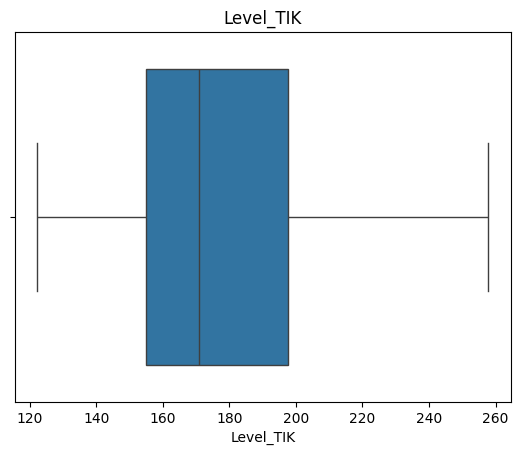

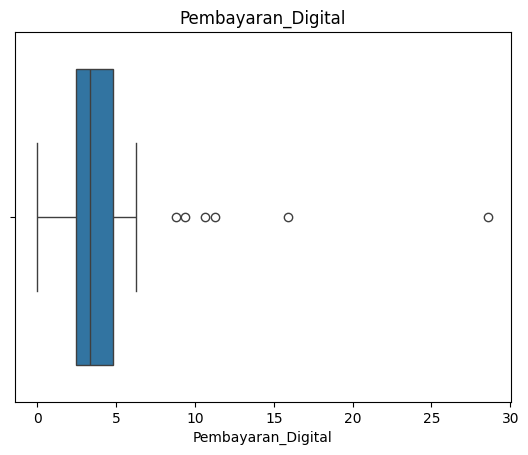

In [211]:
import warnings
warnings.filterwarnings("ignore")

for i in df_imputed.select_dtypes(include="number").columns:
    sns.boxplot(data=df_imputed, x=i)
    plt.title(i)
    plt.show()

In [212]:
from sklearn.preprocessing import MinMaxScaler

# Pisahkan kolom provinsi
provinsi = df_imputed['Provinsi'].copy()
df_num_imp = df_imputed.drop(columns=['Provinsi'])

# Normalisasi
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_num_imp),
    columns=df_num_imp.columns
)
df_scaled.insert(0, 'Provinsi', provinsi.values)

print("✅ Normalisasi selesai — semua variabel dalam rentang [0, 1]")
print(f"Shape data: {df_scaled.shape}")
df_scaled.drop(columns=['Provinsi']).describe().round(3)

✅ Normalisasi selesai — semua variabel dalam rentang [0, 1]
Shape data: (38, 12)


,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,jumlah_UMKM_Nonpertanian,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
count,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000,38.000
mean,0.640,0.899,0.609,0.534,0.125,0.146,0.126,0.571,0.491,0.411,0.168
std,0.174,0.224,0.211,0.197,0.233,0.232,0.232,0.266,0.213,0.249,0.179
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.595,0.911,0.444,0.428,0.022,0.035,0.017,0.381,0.323,0.241,0.086
50%,0.666,0.977,0.577,0.550,0.053,0.063,0.055,0.559,0.478,0.359,0.116
75%,0.705,0.996,0.772,0.650,0.114,0.132,0.105,0.794,0.647,0.557,0.168
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [213]:
# standard scaler
provinsi = df_imputed['Provinsi'].copy()
df_num_imp = df_imputed.drop(columns=['Provinsi'])
scaler_std = StandardScaler()

df_std = pd.DataFrame(scaler_std.fit_transform(df_num_imp), columns=df_num_imp.columns)
df_std.insert(0, 'Provinsi', provinsi.values)

print('Standar')
print(df_std.head())

Standar
         Provinsi       IPM  Infrastruktur_Desa      IMDI  Persen_Ecommerce  \
0            Aceh  0.323018            0.409321  0.464158          0.207488   
1  Sumatera Utara  0.321050            0.175890 -0.197953          0.015677   
2  Sumatera Barat  0.413533            0.331223  0.862486         -0.544547   
3            Riau  0.472565            0.340086 -0.143072          0.146649   
4           Jambi  0.204954            0.359871 -0.681258         -0.109381   

   Jumlah_UMKM  jumlah_UMKM_Nonpertanian  nilai_tambah  Penetrasi_Internet  \
0    -0.035858                 -0.137217     -0.167918            0.091634   
1     0.036475                  0.555607      0.049746           -0.252217   
2    -0.131905                 -0.043982     -0.207326           -0.011279   
3    -0.289813                 -0.172575     -0.288637            0.878618   
4    -0.398552                 -0.362410     -0.397023            1.292692   

   Pelatihan_TIK  Level_TIK  Pembayaran_Digital 

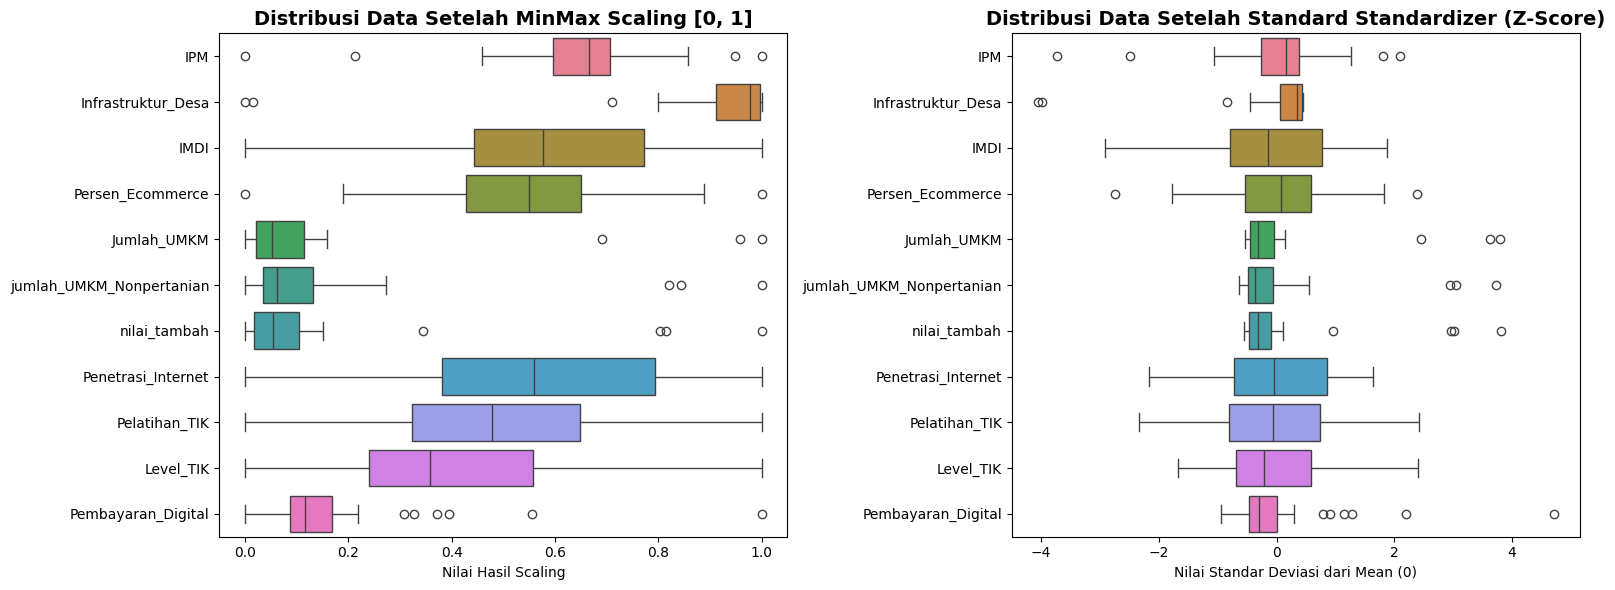

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_scaled.drop(columns=['Provinsi']), ax=axes[0], orient='h')
axes[0].set_title('Distribusi Data Setelah MinMax Scaling [0, 1]', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nilai Hasil Scaling')

sns.boxplot(data=df_std.drop(columns=['Provinsi']), ax=axes[1], orient='h')
axes[1].set_title('Distribusi Data Setelah Standard Standardizer (Z-Score)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nilai Standar Deviasi dari Mean (0)')

plt.tight_layout()
plt.show()

In [215]:
df_num = df_imputed.drop(columns=['Provinsi'])

komparasi = pd.DataFrame(index=df_num.columns)

komparasi['MinMax_Min'] = df_scaled.drop(columns=['Provinsi']).min().round(3)
komparasi['MinMax_Mean'] = df_scaled.drop(columns=['Provinsi']).mean().round(3)
komparasi['MinMax_Max'] = df_scaled.drop(columns=['Provinsi']).max().round(3)

komparasi['StdScaler_Min'] = df_std.drop(columns=['Provinsi']).min().round(3)
komparasi['StdScaler_Mean'] = df_std.drop(columns=['Provinsi']).mean().round(3)
komparasi['StdScaler_Max'] = df_std.drop(columns=['Provinsi']).max().round(3)

print("Tabel Komparasi")
komparasi

Tabel Komparasi


,MinMax_Min,MinMax_Mean,MinMax_Max,StdScaler_Min,StdScaler_Mean,StdScaler_Max
IPM,0.0,0.640,1.0,-3.732,-0.0,2.104
Infrastruktur_Desa,0.0,0.899,1.0,-4.062,-0.0,0.456
IMDI,0.0,0.609,1.0,-2.919,-0.0,1.875
Persen_Ecommerce,0.0,0.534,1.0,-2.746,-0.0,2.395
Jumlah_UMKM,0.0,0.125,1.0,-0.543,-0.0,3.803
jumlah_UMKM_Nonpertanian,0.0,0.146,1.0,-0.639,0.0,3.731
nilai_tambah,0.0,0.126,1.0,-0.550,-0.0,3.821
Penetrasi_Internet,0.0,0.571,1.0,-2.171,-0.0,1.634
Pelatihan_TIK,0.0,0.491,1.0,-2.337,0.0,2.419
Level_TIK,0.0,0.411,1.0,-1.674,-0.0,2.398


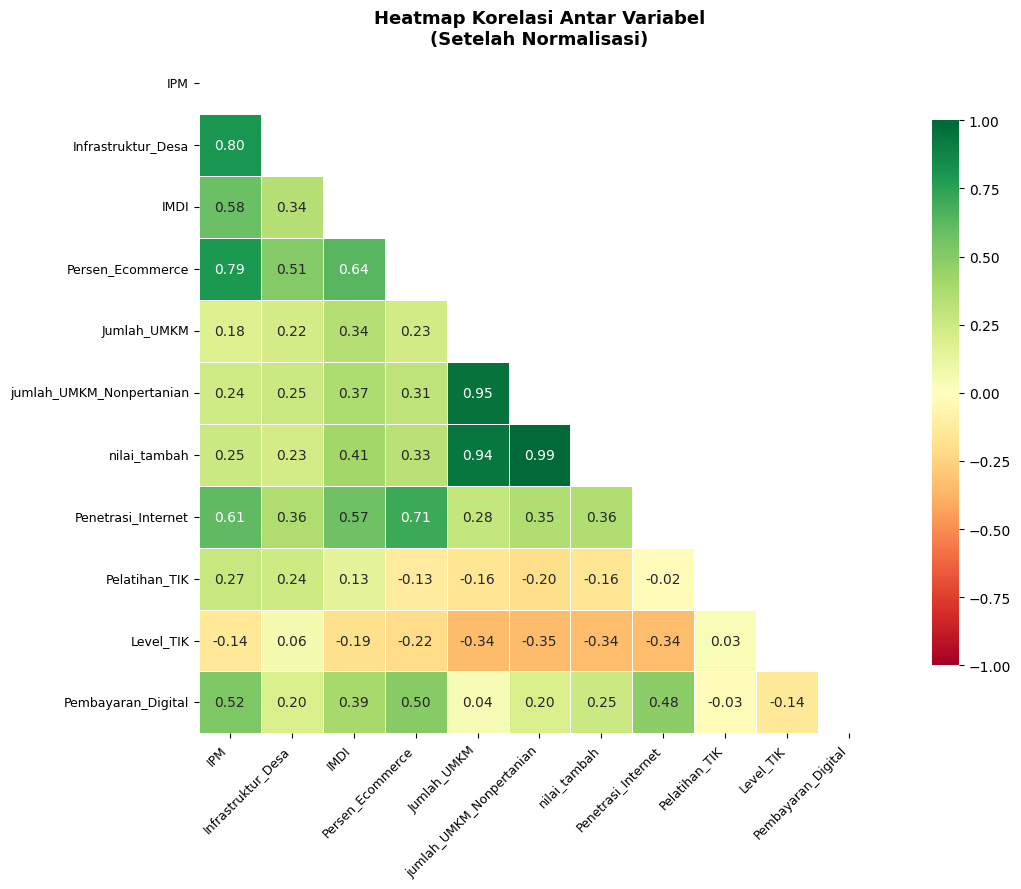


Pasangan variabel dengan korelasi > 0.85:
  Jumlah_UMKM & jumlah_UMKM_Nonpertanian: r = 0.947
  Jumlah_UMKM & nilai_tambah: r = 0.937
  jumlah_UMKM_Nonpertanian & nilai_tambah: r = 0.986


In [216]:
corr = df_scaled.drop(columns=['Provinsi']).corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Heatmap Korelasi Antar Variabel\n(Setelah Normalisasi)',
        fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Tampilkan pasangan korelasi tinggi
print("\nPasangan variabel dengan korelasi > 0.85:")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i,j], 3)))

if high_corr:
    for h in high_corr:
        print(f"  {h[0]} & {h[1]}: r = {h[2]}")
else:
    print("  Tidak ada ✅")

In [217]:
# Drop jumlah_UMKM_Nonpertanian
df_final = df_scaled.drop(columns=['jumlah_UMKM_Nonpertanian'])

print(f"Variabel sebelum drop : {df_scaled.shape[1]-1}")
print(f"Variabel setelah drop : {df_final.shape[1]-1}")
print(f"\nVariabel final:")
for col in df_final.drop(columns=['Provinsi']).columns.tolist():
    print(f"  - {col}")

Variabel sebelum drop : 11
Variabel setelah drop : 10

Variabel final:
  - IPM
  - Infrastruktur_Desa
  - IMDI
  - Persen_Ecommerce
  - Jumlah_UMKM
  - nilai_tambah
  - Penetrasi_Internet
  - Pelatihan_TIK
  - Level_TIK
  - Pembayaran_Digital


In [218]:
#start PCA
from sklearn.decomposition import PCA
import numpy as np

# Siapkan data tanpa kolom Provinsi
X = df_final.drop(columns=['Provinsi']).values
provinsi_label = df_final['Provinsi'].values

print(f"Shape data input PCA: {X.shape}")
print(f"(38 provinsi × 10 variabel)")

Shape data input PCA: (38, 10)
(38 provinsi × 10 variabel)


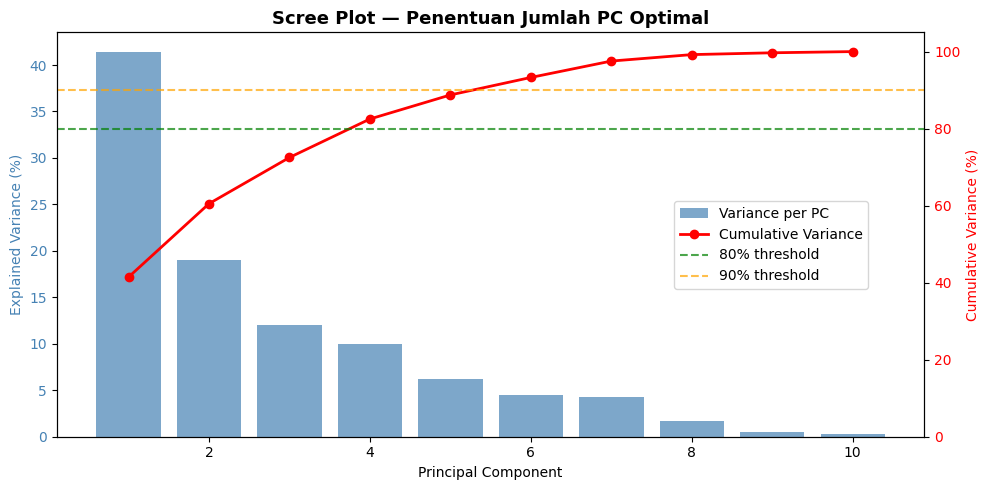


Variance Explained per PC:
PC      Variance (%)  Cumulative (%)
------------------------------------
PC1            41.45           41.45
PC2            19.07           60.51
PC3            12.00           72.51
PC4             9.99           82.50
PC5             6.25           88.75
PC6             4.54           93.28
PC7             4.26           97.54
PC8             1.67           99.22
PC9             0.47           99.69
PC10            0.31          100.00


In [219]:
# Fit PCA dengan semua komponen dulu
pca_full = PCA()
pca_full.fit(X)

# Hitung variance explained
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart variance per PC
ax1.bar(range(1, len(explained_var)+1), explained_var * 100,
        color='steelblue', alpha=0.7, label='Variance per PC')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart cumulative variance
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
        'ro-', linewidth=2, markersize=6, label='Cumulative Variance')
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

plt.title('Scree Plot — Penentuan Jumlah PC Optimal', fontsize=13, fontweight='bold')
fig.legend(loc='center right', bbox_to_anchor=(0.88, 0.5))
plt.tight_layout()
plt.show()

print("\nVariance Explained per PC:")
print(f"{'PC':<6} {'Variance (%)':>13} {'Cumulative (%)':>15}")
print("-" * 36)
for i, (var, cum) in enumerate(zip(explained_var * 100, cumulative_var * 100)):
        print(f"PC{i+1:<4} {var:>13.2f} {cum:>15.2f}")

In [220]:
n_components = np.argmax(cumulative_var >= 0.80) + 1
print(f"Jumlah PC optimal (≥80% variance): {n_components}")

# Fit PCA
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

print(f"\nShape setelah PCA: {X_pca.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Jumlah PC optimal (≥80% variance): 4

Shape setelah PCA: (38, 4)
Total variance explained: 82.50%


In [221]:
df_pca_final = pd.DataFrame(X_pca, columns=[f'PC-{i+1}' for i in range(n_components)])
df_pca_final.insert(0, 'Provinsi', provinsi_label)
print("Tabel Data Hasil Reduksi PCA")
df_pca_final.head()

Tabel Data Hasil Reduksi PCA


,Provinsi,PC-1,PC-2,PC-3,PC-4
0,Aceh,0.019434,-0.182034,0.164667,0.069183
1,Sumatera Utara,-0.006367,0.070101,-0.004468,-0.095007
2,Sumatera Barat,-0.004387,-0.192635,0.157210,0.158785
3,Riau,0.158377,-0.040283,-0.229747,-0.096318
4,Jambi,0.123977,-0.073567,-0.265215,0.050819


Loading Matrix (kontribusi variabel ke tiap PC):
                      PC1    PC2    PC3    PC4
IPM                 0.299 -0.302  0.085  0.058
Infrastruktur_Desa  0.283 -0.345  0.446  0.091
IMDI                0.350 -0.122  0.012  0.006
Persen_Ecommerce    0.354 -0.199 -0.117 -0.235
Jumlah_UMKM         0.324  0.506  0.381  0.038
nilai_tambah        0.363  0.451  0.322 -0.031
Penetrasi_Internet  0.489 -0.171 -0.355 -0.126
Pelatihan_TIK      -0.001 -0.317  0.208  0.765
Level_TIK          -0.248 -0.354  0.572 -0.548
Pembayaran_Digital  0.212 -0.144 -0.187 -0.172


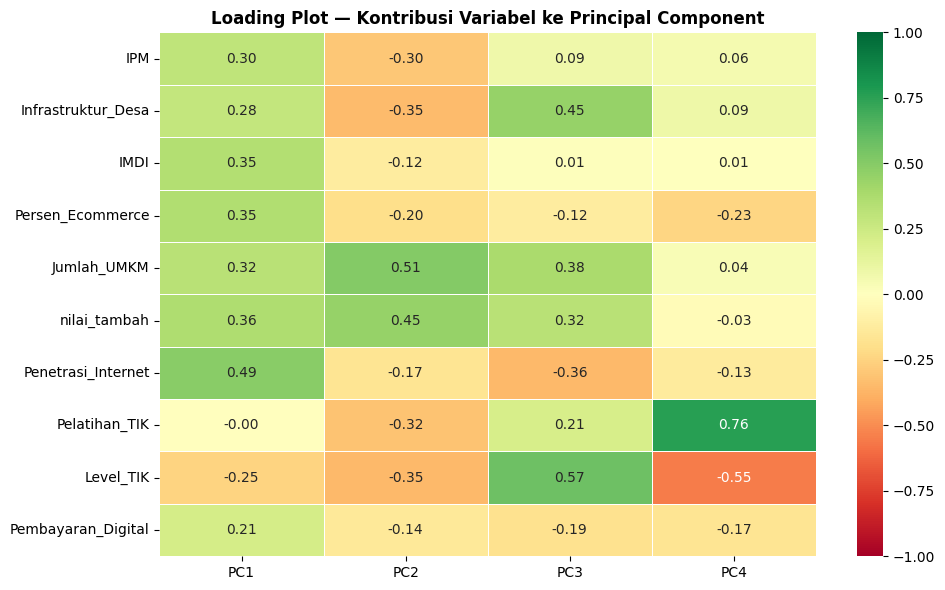

In [222]:
#dataframe loading
feature_names = df_final.drop(columns=['Provinsi']).columns
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print("Loading Matrix (kontribusi variabel ke tiap PC):")
print(loadings.round(3))

# Heatmap loading
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Loading Plot — Kontribusi Variabel ke Principal Component',
        fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Rotasi Varimax

Loading Matrix Setelah Rotasi Varimax:
                    PC1 (Varimax)  PC2 (Varimax)  PC3 (Varimax)  PC4 (Varimax)
IPM                         0.262         -0.009          0.054          0.347
Infrastruktur_Desa          0.106          0.131          0.269          0.552
IMDI                        0.294          0.107         -0.026          0.198
Persen_Ecommerce            0.474          0.002          0.084          0.040
Jumlah_UMKM                -0.084          0.707         -0.028          0.025
nilai_tambah                0.015          0.663         -0.006          0.002
Penetrasi_Internet          0.616         -0.031         -0.173          0.024
Pelatihan_TIK              -0.306         -0.148         -0.291          0.727
Level_TIK                  -0.070         -0.063          0.895          0.057
Pembayaran_Digital          0.351         -0.073          0.009         -0.035


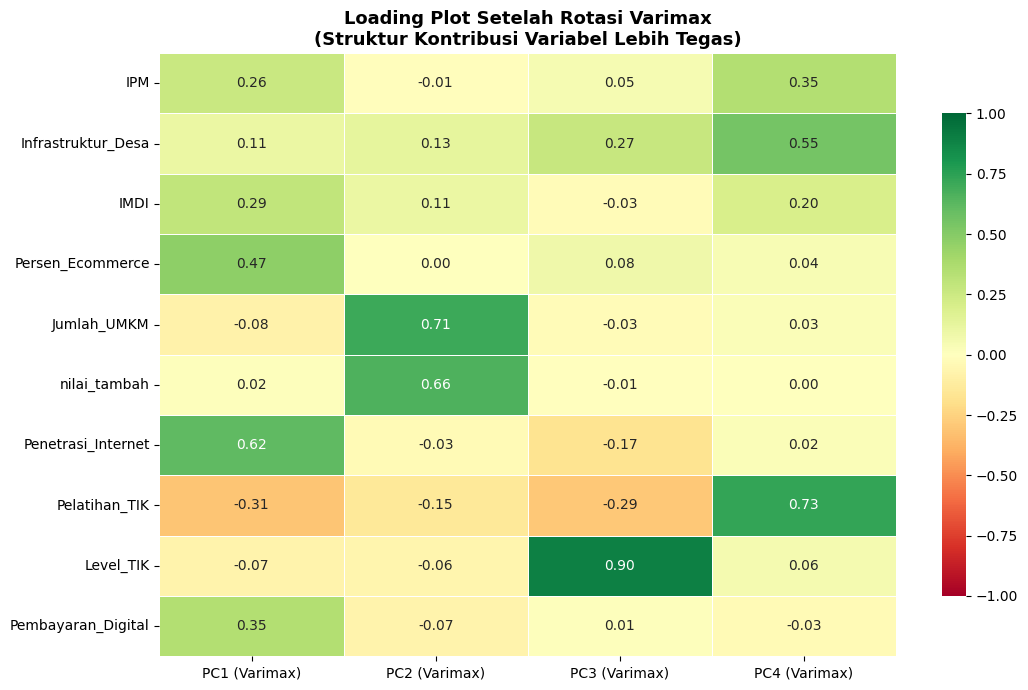

In [223]:
from factor_analyzer import Rotator

current_loadings = pca.components_.T
rotator = Rotator(method='varimax')
loadings_rotated = rotator.fit_transform(current_loadings)

feature_names = df_final.drop(columns=['Provinsi']).columns
df_loadings_rotated = pd.DataFrame(
    loadings_rotated,
    index=feature_names,
    columns=[f'PC{i+1} (Varimax)' for i in range(n_components)]
)

print("Loading Matrix Setelah Rotasi Varimax:")
print(df_loadings_rotated.round(3))

plt.figure(figsize=(11, 7))
sns.heatmap(df_loadings_rotated, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Loading Plot Setelah Rotasi Varimax\n(Struktur Kontribusi Variabel Lebih Tegas)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

X_pca_rotated = np.dot(X, loadings_rotated)

Tanpa PCA

In [224]:
kmeans_tanpa_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_tanpa_pca = kmeans_tanpa_pca.fit_predict(X_tanpa_pca)

df_hasil_tanpa_pca = df_final.copy()
df_hasil_tanpa_pca['Cluster_Tanpa_PCA'] = labels_tanpa_pca

print("Distribusi Anggota per Cluster (Tanpa PCA):")
print(df_hasil_tanpa_pca['Cluster_Tanpa_PCA'].value_counts().sort_index())

# 3. Analisis Profiling: Menghitung rata-rata nilai asli per cluster
print("\nKarakteristik Rata-Rata Variabel per Cluster (Data Asli):")
profil_tanpa_pca = df_hasil_tanpa_pca.drop(columns=['Provinsi']).groupby('Cluster_Tanpa_PCA').mean()
print(profil_tanpa_pca.round(3))

Distribusi Anggota per Cluster (Tanpa PCA):
Cluster_Tanpa_PCA
0     3
1    17
2    16
3     2
Name: count, dtype: int64

Karakteristik Rata-Rata Variabel per Cluster (Data Asli):
                     IPM  Infrastruktur_Desa   IMDI  Persen_Ecommerce  \
Cluster_Tanpa_PCA                                                       
0                  0.698               1.000  0.814             0.647   
1                  0.602               0.914  0.517             0.421   
2                  0.735               0.976  0.692             0.674   
3                  0.107               0.008  0.417             0.214   

                   Jumlah_UMKM  nilai_tambah  Penetrasi_Internet  \
Cluster_Tanpa_PCA                                                  
0                        0.883         0.872               0.814   
1                        0.053         0.040               0.380   
2                        0.075         0.092               0.767   
3                        0.002         0.0

In [225]:
for c in sorted(df_hasil_tanpa_pca['Cluster_Tanpa_PCA'].unique()):
    print(f"\Cluster {c}:")
    prov_list = df_hasil_tanpa_pca[df_hasil_tanpa_pca['Cluster_Tanpa_PCA'] == c]['Provinsi'].tolist()
    print(f"Jumlah: {len(prov_list)} Provinsi")
    print(prov_list)

\Cluster 0:
Jumlah: 3 Provinsi
['Jawa Barat', 'Jawa Tengah', 'Jawa Timur']
\Cluster 1:
Jumlah: 17 Provinsi
['Aceh', 'Sumatera Barat', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Kalimantan Selatan', 'Kalimantan Utara', 'Sulawesi Utara', 'Sulawesi Tengah', 'Sulawesi Tenggara', 'Gorontalo', 'Sulawesi Barat', 'Maluku', 'Maluku Utara', 'Papua Barat', 'Papua Barat Daya', 'Papua', 'Papua Selatan']
\Cluster 2:
Jumlah: 16 Provinsi
['Sumatera Utara', 'Riau', 'Jambi', 'Sumatera Selatan', 'Bengkulu', 'Lampung', 'Kep. Bangka Belitung', 'Kepulauan Riau', 'DKI Jakarta', 'D.I. Yogyakarta', 'Banten', 'Bali', 'Kalimantan Barat', 'Kalimantan Tengah', 'Kalimantan Timur', 'Sulawesi Selatan']
\Cluster 3:
Jumlah: 2 Provinsi
['Papua Tengah', 'Papua Pegunungan']


In [226]:
for c in sorted(df_hasil_tanpa_pca['Cluster_Tanpa_PCA'].unique()):
    nama_klaster = ["Raksasa Ekonomi & Infrastruktur Paripurna", "Wilayah Berkembang & Dorongan Literasi TIK", 
                    "Hub Digital Utama & Adopsi Pasar Tinggi", "Keterbatasan Akses & Infrastruktur"][c]
    
    prov_list = df_hasil_tanpa_pca[df_hasil_tanpa_pca['Cluster_Tanpa_PCA'] == c]['Provinsi'].tolist()
    
    print(f"Klaster {c} : {nama_klaster} ({len(prov_list)} Provinsi)")
    print(", ".join(prov_list))
    print("\n")

Klaster 0 : Raksasa Ekonomi & Infrastruktur Paripurna (3 Provinsi)
Jawa Barat, Jawa Tengah, Jawa Timur


Klaster 1 : Wilayah Berkembang & Dorongan Literasi TIK (17 Provinsi)
Aceh, Sumatera Barat, Nusa Tenggara Barat, Nusa Tenggara Timur, Kalimantan Selatan, Kalimantan Utara, Sulawesi Utara, Sulawesi Tengah, Sulawesi Tenggara, Gorontalo, Sulawesi Barat, Maluku, Maluku Utara, Papua Barat, Papua Barat Daya, Papua, Papua Selatan


Klaster 2 : Hub Digital Utama & Adopsi Pasar Tinggi (16 Provinsi)
Sumatera Utara, Riau, Jambi, Sumatera Selatan, Bengkulu, Lampung, Kep. Bangka Belitung, Kepulauan Riau, DKI Jakarta, D.I. Yogyakarta, Banten, Bali, Kalimantan Barat, Kalimantan Tengah, Kalimantan Timur, Sulawesi Selatan


Klaster 3 : Keterbatasan Akses & Infrastruktur (2 Provinsi)
Papua Tengah, Papua Pegunungan




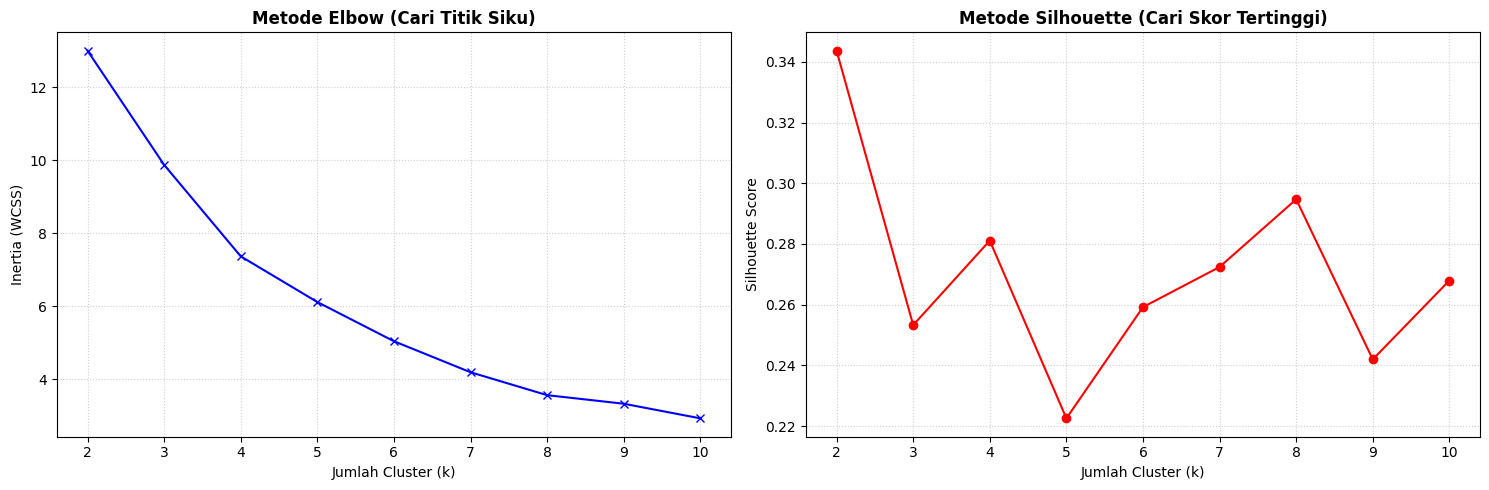

Hasil Evaluasi K-Means:
k     Inertia         Silhouette Score
--------------------------------------
2     13.00           0.3437         
3     9.88            0.2533         
4     7.37            0.2811         
5     6.12            0.2225         
6     5.04            0.2592         
7     4.20            0.2724         
8     3.57            0.2947         
9     3.33            0.2420         
10    2.93            0.2679         


In [227]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_tanpa_pca)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_tanpa_pca, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range, inertia, 'bx-')
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Metode Elbow (Cari Titik Siku)', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Jumlah Cluster (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Metode Silhouette (Cari Skor Tertinggi)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("Hasil Evaluasi K-Means:")
print(f"{'k':<5} {'Inertia':<15} {'Silhouette Score':<15}")
print("-" * 38)
for i, k in enumerate(K_range):
    print(f"{k:<5} {inertia[i]:<15.2f} {silhouette_scores[i]:<15.4f}")

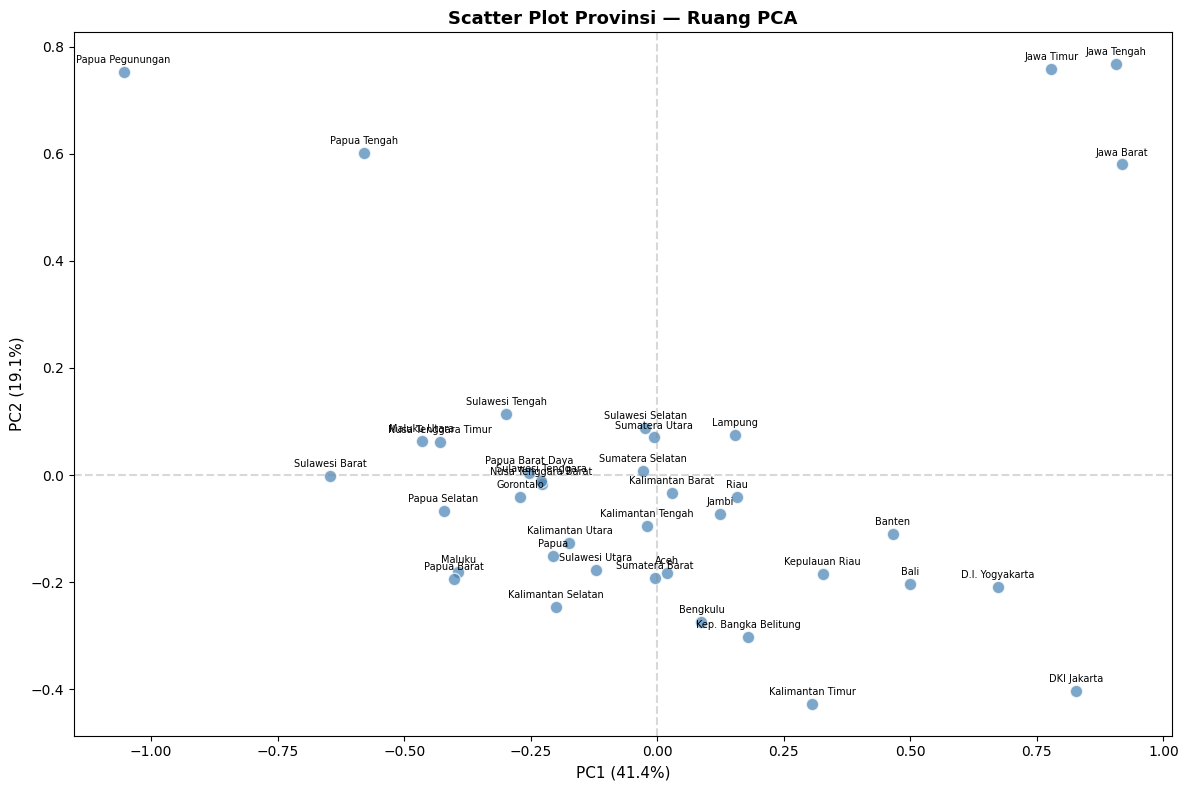

In [228]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c='steelblue', s=80, alpha=0.7, edgecolors='white')

# Tambah label provinsi
for i, prov in enumerate(provinsi_label):
    plt.annotate(prov, (X_pca[i, 0], X_pca[i, 1]),
                 fontsize=7, ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
plt.title('Scatter Plot Provinsi — Ruang PCA', fontsize=13, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

INI START HDBSCAN

In [229]:
import hdbscan
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from itertools import product

In [230]:
best_score = -1
best_params = {}
results = []

for min_cluster, min_samp in product(range(2, 8), range(1, 6)):
    hdb_test = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster,
        min_samples=min_samp
    )

    labels = hdb_test.fit_predict(X_pca_rotated)
    mask = labels != -1
    
    n_clusters = len(set(labels[mask]))
    n_noise = list(labels).count(-1)

    if n_clusters > 1 and sum(mask) > n_clusters:
        sil = silhouette_score(X_pca_rotated[mask], labels[mask])
        dbi = davies_bouldin_score(X_pca_rotated[mask], labels[mask])
        
        results.append({'min_cluster_size': min_cluster, 'min_samples': min_samp, 'n_clusters': n_clusters, 'n_noise': n_noise,
            'silhouette': round(sil, 3), 'dbi': round(dbi, 3)})
        
        if sil > best_score:
            best_score = sil
            best_params = {'min_cluster_size': min_cluster, 'min_samples': min_samp}

df_tuning = pd.DataFrame(results).sort_values('silhouette', ascending=False)
print("Top 10 kombinasi parameter terbaik setelah Varimax:")
print(df_tuning.head(10).to_string(index=False))
print(f"\nParameter terbaik: {best_params}")
print(f"Silhouette Score : {best_score:.3f}")

Top 10 kombinasi parameter terbaik setelah Varimax:
 min_cluster_size  min_samples  n_clusters  n_noise  silhouette   dbi
                2            2           2        2       0.560 0.452
                3            2           2        2       0.560 0.452
                3            1           2        2       0.560 0.452
                2            1           3        0       0.520 0.573
                2            4           2       26       0.445 0.775
                4            4           2       26       0.445 0.775
                3            4           2       26       0.445 0.775
                6            4           2       26       0.445 0.775
                5            4           2       26       0.445 0.775
                6            3           2       21       0.421 0.886

Parameter terbaik: {'min_cluster_size': 2, 'min_samples': 2}
Silhouette Score : 0.560


In [231]:
labels = hdb_test.fit_predict(X_pca_rotated)

hdb = hdbscan.HDBSCAN(
    min_cluster_size=best_params['min_cluster_size'],
    min_samples=best_params['min_samples']
)
hdb_labels = hdb.fit_predict(X_pca_rotated)

df_hdbscan = df_final[['Provinsi']].copy()
df_hdbscan['Cluster_HDBSCAN'] = hdb_labels

print(f"Parameter: min_cluster_size={best_params['min_cluster_size']}, min_samples={best_params['min_samples']}")
print(f"Jumlah cluster : {len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)}")
print(f"Jumlah noise   : {list(hdb_labels).count(-1)}")
print("\nDistribusi cluster:")
print(df_hdbscan['Cluster_HDBSCAN'].value_counts().sort_index())

print("\nIsi tiap cluster:")
for c in sorted(df_hdbscan['Cluster_HDBSCAN'].unique()):
    label = "Noise" if c == -1 else f"Cluster {c}"
    print(f"\n{label}:")
    print(df_hdbscan[df_hdbscan['Cluster_HDBSCAN']==c]['Provinsi'].tolist())

Parameter: min_cluster_size=2, min_samples=2
Jumlah cluster : 2
Jumlah noise   : 2

Distribusi cluster:
Cluster_HDBSCAN
-1     2
 0     3
 1    33
Name: count, dtype: int64

Isi tiap cluster:

Noise:
['Papua Tengah', 'Papua Pegunungan']

Cluster 0:
['Jawa Barat', 'Jawa Tengah', 'Jawa Timur']

Cluster 1:
['Aceh', 'Sumatera Utara', 'Sumatera Barat', 'Riau', 'Jambi', 'Sumatera Selatan', 'Bengkulu', 'Lampung', 'Kep. Bangka Belitung', 'Kepulauan Riau', 'DKI Jakarta', 'D.I. Yogyakarta', 'Banten', 'Bali', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Kalimantan Barat', 'Kalimantan Tengah', 'Kalimantan Selatan', 'Kalimantan Timur', 'Kalimantan Utara', 'Sulawesi Utara', 'Sulawesi Tengah', 'Sulawesi Selatan', 'Sulawesi Tenggara', 'Gorontalo', 'Sulawesi Barat', 'Maluku', 'Maluku Utara', 'Papua Barat', 'Papua Barat Daya', 'Papua', 'Papua Selatan']


EVALUASI HBDSCAN

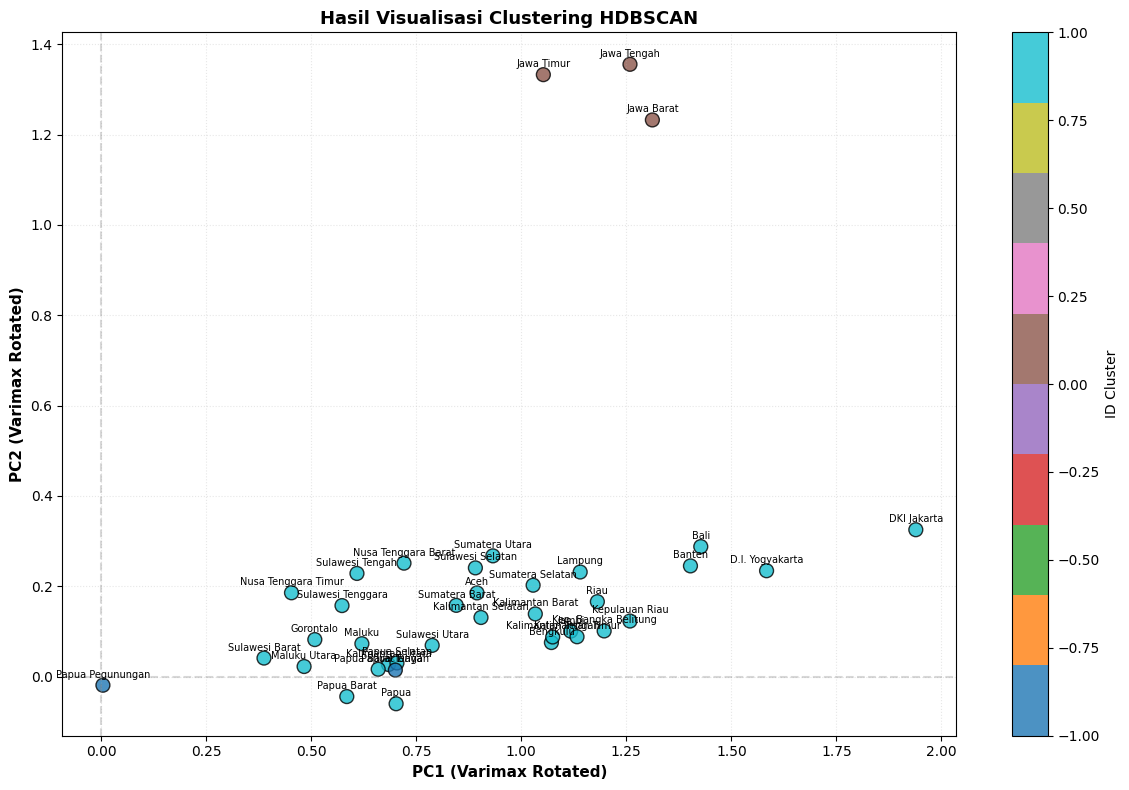

In [232]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca_rotated[:, 0], X_pca_rotated[:, 1],
    c=hdb_labels, cmap='tab10',
    s=100, alpha=0.8, edgecolors='black'
)
for i, prov in enumerate(provinsi_label):
    plt.annotate(prov, (X_pca_rotated[i, 0], X_pca_rotated[i, 1]), fontsize=7, ha='center', va='bottom', xytext=(0,4), textcoords='offset points')

plt.xlabel('PC1 (Varimax Rotated)', fontsize=11, fontweight='bold')
plt.ylabel('PC2 (Varimax Rotated)', fontsize=11, fontweight='bold')
plt.title('Hasil Visualisasi Clustering HDBSCAN', fontsize=13, fontweight='bold')
plt.colorbar(label='ID Cluster')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.grid(alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

In [233]:
# Silhouette & DBI (exclude noise)
mask_hdb = hdb_labels != -1

if len(set(hdb_labels[mask_hdb])) > 1:
    sil_hdb = silhouette_score(X_pca_rotated[mask_hdb], hdb_labels[mask_hdb])
    dbi_hdb = davies_bouldin_score(X_pca_rotated[mask_hdb], hdb_labels[mask_hdb])
    print(f"HDBSCAN — Silhouette Score : {sil_hdb:.3f}")
    print(f"HDBSCAN — Davies-Bouldin   : {dbi_hdb:.3f} ")
else:
    print("Tidak cukup cluster untuk evaluasi")

HDBSCAN — Silhouette Score : 0.560
HDBSCAN — Davies-Bouldin   : 0.452 


START GMM

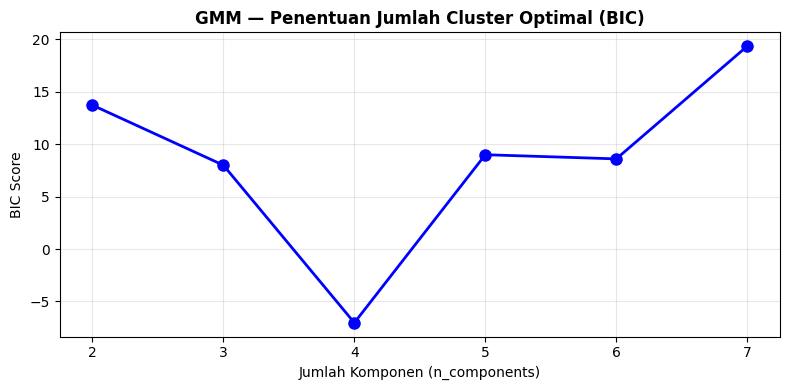

Jumlah cluster optimal GMM: 4 (BIC terendah)


In [234]:
#jumla komponen GMM optimal
bic_scores = []
n_range = range(2, 8)

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

plt.figure(figsize=(8, 4))
plt.plot(n_range, bic_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Komponen (n_components)')
plt.ylabel('BIC Score')
plt.title('GMM — Penentuan Jumlah Cluster Optimal (BIC)', fontsize=12, fontweight='bold')
plt.xticks(n_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_optimal = n_range[bic_scores.index(min(bic_scores))]
print(f"Jumlah cluster optimal GMM: {n_optimal} (BIC terendah)")

In [235]:
gmm = GaussianMixture(n_components=n_optimal, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

df_gmm = df_final[['Provinsi']].copy()
df_gmm['Cluster_GMM'] = gmm_labels

print("Distribusi cluster GMM:")
print(df_gmm['Cluster_GMM'].value_counts().sort_index())

print("\nIsi tiap cluster:")
for c in sorted(df_gmm['Cluster_GMM'].unique()):
    print(f"\nCluster {c}:")
    print(df_gmm[df_gmm['Cluster_GMM']==c]['Provinsi'].tolist())

Distribusi cluster GMM:
Cluster_GMM
0     3
1    16
2    17
3     2
Name: count, dtype: int64

Isi tiap cluster:

Cluster 0:
['Jawa Barat', 'Jawa Tengah', 'Jawa Timur']

Cluster 1:
['Aceh', 'Sumatera Barat', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Kalimantan Selatan', 'Kalimantan Utara', 'Sulawesi Utara', 'Sulawesi Tengah', 'Sulawesi Tenggara', 'Gorontalo', 'Sulawesi Barat', 'Maluku', 'Maluku Utara', 'Papua Barat', 'Papua', 'Papua Selatan']

Cluster 2:
['Sumatera Utara', 'Riau', 'Jambi', 'Sumatera Selatan', 'Bengkulu', 'Lampung', 'Kep. Bangka Belitung', 'Kepulauan Riau', 'DKI Jakarta', 'D.I. Yogyakarta', 'Banten', 'Bali', 'Kalimantan Barat', 'Kalimantan Tengah', 'Kalimantan Timur', 'Sulawesi Selatan', 'Papua Barat Daya']

Cluster 3:
['Papua Tengah', 'Papua Pegunungan']


EVALUASI GMM

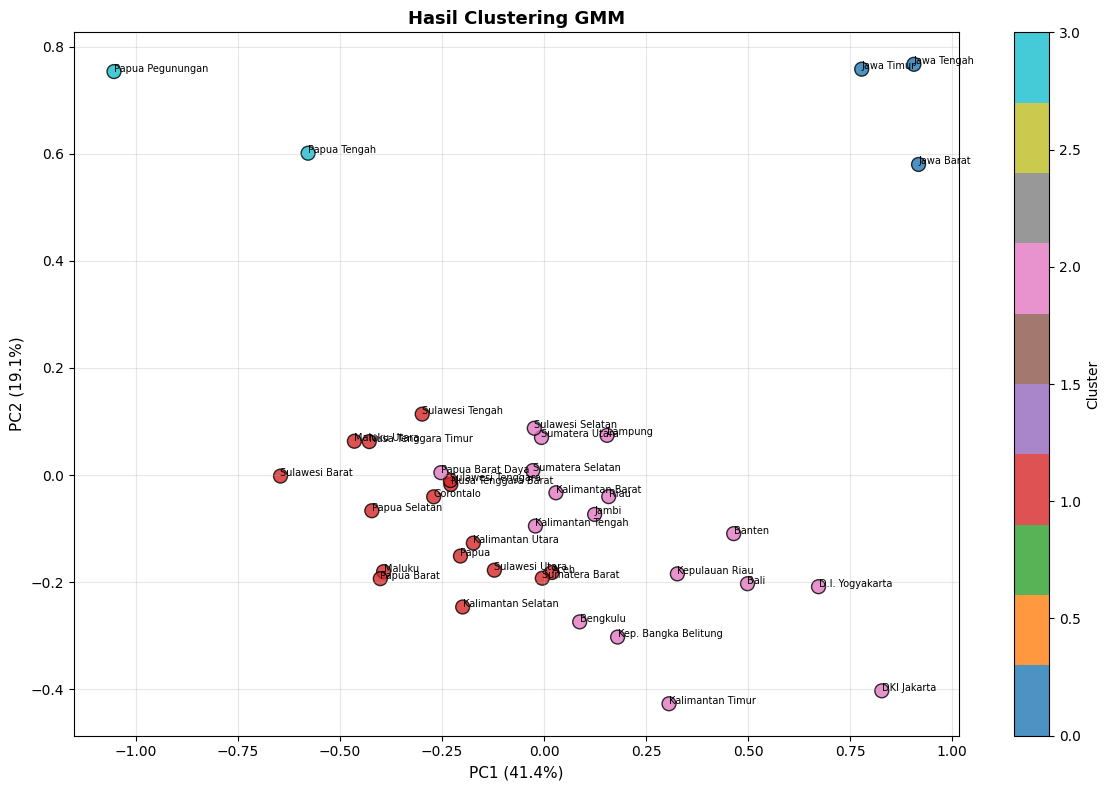

In [236]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=gmm_labels, cmap='tab10',
    s=100, alpha=0.8, edgecolors='black'
)
for i, prov in enumerate(provinsi_label):
    plt.annotate(prov, (X_pca[i, 0], X_pca[i, 1]), fontsize=7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
plt.title('Hasil Clustering GMM', fontsize=13, fontweight='bold')
plt.colorbar(label='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [237]:
sil_gmm = silhouette_score(X_pca, gmm_labels)
dbi_gmm = davies_bouldin_score(X_pca, gmm_labels)

print(f"GMM — Silhouette Score : {sil_gmm:.3f}")
print(f"GMM — Davies-Bouldin   : {dbi_gmm:.3f}")

GMM — Silhouette Score : 0.350
GMM — Davies-Bouldin   : 0.832


KOMPARASI HBDSCAN DAN GMM

In [238]:
print("=" * 50)
print("KOMPARASI HDBSCAN vs GMM")
print("=" * 50)
print(f"{'Metrik':<25} {'HDBSCAN':>10} {'GMM':>10}")
print("-" * 50)
print(f"{'Silhouette Score':<25} {sil_hdb:>10.3f} {sil_gmm:>10.3f}")
print(f"{'Davies-Bouldin Index':<25} {dbi_hdb:>10.3f} {dbi_gmm:>10.3f}")
print(f"{'Jumlah Cluster':<25} {len(set(hdb_labels))-(1 if -1 in hdb_labels else 0):>10} {n_optimal:>10}")
print("=" * 50)

# Kesimpulan otomatis
if sil_hdb > sil_gmm and dbi_hdb < dbi_gmm:
    print("\n✅ HDBSCAN lebih optimal")
elif sil_gmm > sil_hdb and dbi_gmm < dbi_hdb:
    print("\n✅ GMM lebih optimal")
else:
    print("\n⚠️  Hasil mixed — perlu interpretasi lebih lanjut")

KOMPARASI HDBSCAN vs GMM
Metrik                       HDBSCAN        GMM
--------------------------------------------------
Silhouette Score               0.560      0.350
Davies-Bouldin Index           0.452      0.832
Jumlah Cluster                     2          4

✅ HDBSCAN lebih optimal
